In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from collections import defaultdict

from xgboost import XGBClassifier
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
import joblib
import hashlib


In [33]:
# Import data:
# run script from the data_input file
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    
df_factor = df_factor.set_index('Date')

df = pd.read_csv("lagged_data.csv", parse_dates=['Date'])
df = df.set_index('Date')


data = pd.concat([df,df_factor], axis=1, join='inner')
data = data.dropna()

print(data)

            VolTermStructPC1  VolTermStructPC2  MichgnConcIndx  \
Date                                                             
2008-06-30         43.764525          6.157399            59.8   
2008-07-07         47.865713          4.654912            59.8   
2008-07-14         44.722107          5.007951            59.8   
2008-07-21         46.645075          4.146473            59.8   
2008-07-28         47.943107          3.404113            56.4   
...                      ...               ...             ...   
2023-12-04         35.323792         -9.273054            63.8   
2023-12-11         34.731196         -9.047533            63.8   
2023-12-18         32.986408         -9.509044            63.8   
2023-12-25         32.143726         -9.766372            63.8   
2024-01-01         32.753330         -9.716542            61.3   

            RandPPP_Factor_Inst_TS_ST  BCMPEBLS.Index  PPP.ZA.Index_QS  \
Date                                                               

In [34]:
# ========================
# Phase 1: Combinatorial Purged CV
# ========================
CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 24
FINAL_TEST_POINTS = 156   # 3 years of unseen data

class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)."""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        # Create fold boundaries
        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)

        # Generate test fold combinations
        for test_fold_indices in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)

            # Collect test indices
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                test_mask[start:end] = True

            # Train mask is everything else
            train_mask = ~test_mask

            # Purge around each test fold
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]

                # purge before
                train_mask[max(0, start - self.purge_gap): start] = False
                # purge after
                train_mask[end: min(n_samples, end + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]
    
    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)
"""

def tune_hyperparameters(X, y):
    
    cv = CombinatorialPurgedCV()

    param_grid = {
        'learning_rate': [0.01, 0.5, 1],
        'max_depth': [3, 8, 16, 32],
        'subsample': [0.4, 0.7, 1.0],
        'colsample_bytree': [0.4, 0.7, 1.0],
        'base_score': [0.5,0.6,0.7]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        model = XGBClassifier(objective='binary:logistic',
                              eval_metric='logloss',
                              n_estimators=1000,
                              **params)
        
        fold_scores = []
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train, verbose=False)
            score = roc_auc_score(y_test, model.predict(X_test))
            fold_scores.append(score)
        
        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))

        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (accuracy: {best_score:.3f})")
    
    # Report top 5
    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")
    
    return best_params
"""

def tune_hyperparameters(X, y):
    """Grid search over CPCV folds."""
    cv = CombinatorialPurgedCV()

    param_grid = {
        'learning_rate': [0.01, 0.1, 0.3],     # slightly more realistic grid
        'max_depth': [3, 6, 10],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'base_score': [0.5, 0.6, 0.7]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):

        fold_scores = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                n_estimators=500,          # you can adjust
                #use_label_encoder=False,
                **params
            )

            model.fit(X_train, y_train, verbose=False)

            # IMPORTANT: use probabilities, not class labels
            y_prob = model.predict_proba(X_test)[:, 1]
            score = roc_auc_score(y_test, y_prob)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))

        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (AUC: {best_score:.3f})")

    # Report top 5
    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")

    return best_params



In [35]:
def window_signature(X):
    """
    Create a stable, compact signature for a rolling window
    based on its mean and std across features.
    Used for hyperparameter caching.
    """
    stats = np.concatenate([X.mean(axis=0), X.std(axis=0)])
    stats_bytes = stats.tobytes()
    return hashlib.sha1(stats_bytes).hexdigest()


In [36]:
# ========================
# Phase 2: Walk-Forward Validation
# ========================
"""
def walk_forward_validation(X, y, n_test, base_params, retune_every=None):

    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()
    
    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")
    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue
        
        X_train, X_test = X[:train_size], X[train_size:train_size+1]
        y_train, y_test = y[:train_size], y[train_size:train_size+1]
        
        # Re-tune hyperparameters
        if retune_every is not None and i > 0 and i % retune_every == 0:
            print(f"\n--- Retuning at step {i}, train_size={train_size} ---")
            current_params = tune_hyperparameters(X_train, y_train)
        
        # Fit model
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=1000,
            **current_params
        )
        model.fit(X_train, y_train, verbose=False)
        
        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])
    
    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))
    
    return np.array(actuals), np.array(predictions), np.array(probabilities)

"""

'\ndef walk_forward_validation(X, y, n_test, base_params, retune_every=None):\n\n    actuals, predictions, probabilities = [], [], []\n    current_params = base_params.copy()\n    \n    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")\n    for i in tqdm(range(n_test)):\n        train_size = len(X) - n_test + i\n        if train_size <= 0:\n            continue\n        \n        X_train, X_test = X[:train_size], X[train_size:train_size+1]\n        y_train, y_test = y[:train_size], y[train_size:train_size+1]\n        \n        # Re-tune hyperparameters\n        if retune_every is not None and i > 0 and i % retune_every == 0:\n            print(f"\n--- Retuning at step {i}, train_size={train_size} ---")\n            current_params = tune_hyperparameters(X_train, y_train)\n        \n        # Fit model\n        model = XGBClassifier(\n            objective=\'binary:logistic\',\n            eval_metric=\'logloss\',\n            n_estimators=1000,\n            **curre

In [ ]:
def walk_forward_validation(
    X, y, n_test, base_params,
    retune_every=52, lookback=260
):
    """
    Rolling-window walk-forward with adaptive hyperparameter tuning
    and hyperparameter caching based on window signatures.
    """
    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()

    hyperparam_cache = {}  # signature -> best_params

    print(f"\nRunning Rolling-Window Walk-Forward Validation...")
    print(f"Lookback window = {lookback} samples")

    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        # Rolling window
        start = max(0, train_size - lookback)
        X_train = X[start:train_size]
        y_train = y[start:train_size]

        X_test  = X[train_size:train_size+1]
        y_test  = y[train_size:train_size+1]

        # Adaptive hyperparameter tuning with caching
        if retune_every is not None and i > 0 and i % retune_every == 0:
            sig = window_signature(X_train)

            if sig in hyperparam_cache:
                print(f"\nReusing cached params at step {i}")
                current_params = hyperparam_cache[sig]
            else:
                print(f"\n--- Retuning at step {i}, train_size={train_size} ---")
                current_params = tune_hyperparameters(X_train, y_train)
                hyperparam_cache[sig] = current_params

        # Fit model with current_params
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=500,
            #use_label_encoder=False,
            **current_params
        )

        model.fit(X_train, y_train, verbose=False)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        predictions.append(int(y_pred[0]))
        actuals.append(int(y_test[0]))
        probabilities.append(float(y_prob[0]))

    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))

    return (
        np.array(actuals),
        np.array(predictions),
        np.array(probabilities)
    )


In [38]:
# ========================
# Phase 3: Plotting
# ========================
def plot_wfv_results(actuals, predictions, probabilities):
    auc = roc_auc_score(actuals, probabilities)
    avg_prec = average_precision_score(actuals, probabilities)

    print(f"ROC AUC: {auc:.3f}")
    print(f"Average Precision (PR AUC): {avg_prec:.3f}")

    # Timeline plot
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual', marker='o')
    plt.plot(predictions, label='Predicted', marker='x')
    plt.plot(probabilities, label='Probability', linestyle='--', alpha=0.5)
    plt.title('Walk-Forward Validation Results')
    plt.legend()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(actuals, probabilities)
    plt.figure(figsize=(6, 6))
    #plt.plot(rec, prec, label=f'PR Curve (AP = {avg_prec:.3f})', color='purple')
    plt.step(rec, prec, where='post', color='purple',
         label=f'PR Curve (AP = {avg_prec:.3f})')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(actuals, predictions)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()



In [39]:
# ========================
# Main Entry Point
# ========================

# Data import:
"""
def main():
    # Prepare data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

    # Phase 1: Tune hyperparameters once on training set 
    # parameters used for fixed parameters
    # initial tuning for addptive parameters
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X, y)

    # Phase 2: Walk-forward evaluation
    print("\n=== PHASE 2: FINAL EVALUATION ===")

    # Fixed params - no tunning set retune_every=None
    actuals, preds, probs = walk_forward_validation(
        X, y, FINAL_TEST_POINTS, best_params, retune_every=None
    )

    # Adaptive params - set months using retune_every=n
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X, y, FINAL_TEST_POINTS, best_params, retune_every=52
    )

    # Phase 3: Plots
    print("\n=== Fixed Params ===")
    plot_wfv_results(actuals, preds, probs)

    print("\n=== Adaptive Params ===")
    plot_wfv_results(actuals_adapt, preds_adapt, probs_adapt)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "fixed": (actuals, preds, probs),
        "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    }


if __name__ == "__main__":
    results = main()
"""

'\ndef main():\n    # Prepare data\n    X = data.iloc[:, :-1].values\n    y = data.iloc[:, -1].values\n    feature_names = data.columns[:-1].tolist()\n    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)\n\n    # Phase 1: Tune hyperparameters once on training set \n    # parameters used for fixed parameters\n    # initial tuning for addptive parameters\n    print("=== PHASE 1: HYPERPARAMETER TUNING ===")\n    best_params = tune_hyperparameters(X, y)\n\n    # Phase 2: Walk-forward evaluation\n    print("\n=== PHASE 2: FINAL EVALUATION ===")\n\n    # Fixed params - no tunning set retune_every=None\n    actuals, preds, probs = walk_forward_validation(\n        X, y, FINAL_TEST_POINTS, best_params, retune_every=None\n    )\n\n    # Adaptive params - set months using retune_every=n\n    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(\n        X, y, FINAL_TEST_POINTS, best_params, retune_every=52\n    )\n\n    # Phase 3: Plots\n    print("\n=== Fixed Params ==="

=== PHASE 1: INITIAL HYPERPARAMETER TUNING ===
Testing 243 parameter combinations...


New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.549)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.8} (AUC: 0.552)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 1.0} (AUC: 0.562)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 10, 'subsample': 0.8} (AUC: 0.571)
New best params: {'base_score': 0.5, 'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.6} (AUC: 0.572)
New best params: {'base_score': 0.5, 'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 1.0} (AUC: 0.576)
New best params: {'base_score': 0.6, 'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 10, 'subsample': 1.0} (AUC: 0.581)
New best params: {'base_score': 0.7, 'colsample_bytree': 1.0, 'learning_rat

  0%|          | 0/156 [00:00<?, ?it/s]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:51:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
  1%|          | 1/156 [00:01<03:04,  1.19s/it]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:51:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
  1%|▏         | 2/156 [00:02<03:18,  1.29s/it]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:51:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
  2%|▏         | 3/156 [00:03<03:15,  1.28s/it]c


--- Retuning at step 52, train_size=706 ---
Testing 243 parameter combinations...
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.500)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8} (AUC: 0.512)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 1.0} (AUC: 0.539)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.3, 'max_depth': 3, 'subsample': 1.0} (AUC: 0.547)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.3, 'max_depth': 10, 'subsample': 1.0} (AUC: 0.558)
New best params: {'base_score': 0.5, 'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 3, 'subsample': 1.0} (AUC: 0.570)

=== Top 5 Parameter Combinations ===
Score: 0.570 | Params: {'base_score': 0.5, 'colsample_bytree': 1.0, 'learning_rate': 0.3,

c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:06:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 35%|███▍      | 54/156 [14:33<4:48:25, 169.66s/it]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:06:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 36%|███▌      | 56/156 [14:34<2:18:53, 83.34s/it] c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:06:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 38%|███▊      | 59/156 [14:35<46:38, 28.85s/it]  c:\Users\p528552\AppData\Loca


--- Retuning at step 104, train_size=758 ---
Testing 243 parameter combinations...
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.522)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.8} (AUC: 0.529)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.573)
New best params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.3, 'max_depth': 3, 'subsample': 0.6} (AUC: 0.589)

=== Top 5 Parameter Combinations ===
Score: 0.589 | Params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.3, 'max_depth': 3, 'subsample': 0.6}
Score: 0.579 | Params: {'base_score': 0.5, 'colsample_bytree': 0.6, 'learning_rate': 0.3, 'max_depth': 3, 'subsample': 0.8}
Score: 0.578 | Params: {'base_score': 0.7, 'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3

c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:22:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 68%|██████▊   | 106/156 [31:05<2:50:22, 204.45s/it]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:22:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 69%|██████▊   | 107/156 [31:06<1:57:01, 143.30s/it]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:22:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 70%|██████▉   | 109/156 [31:07<55:13, 70.49s/it]   c:\Users\p528552\AppData\


=== Final Evaluation Results ===
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        76
           1       0.73      0.75      0.74        80

    accuracy                           0.73       156
   macro avg       0.73      0.73      0.73       156
weighted avg       0.73      0.73      0.73       156


=== ADAPTIVE PARAMS RESULTS ===
ROC AUC: 0.783
Average Precision (PR AUC): 0.769


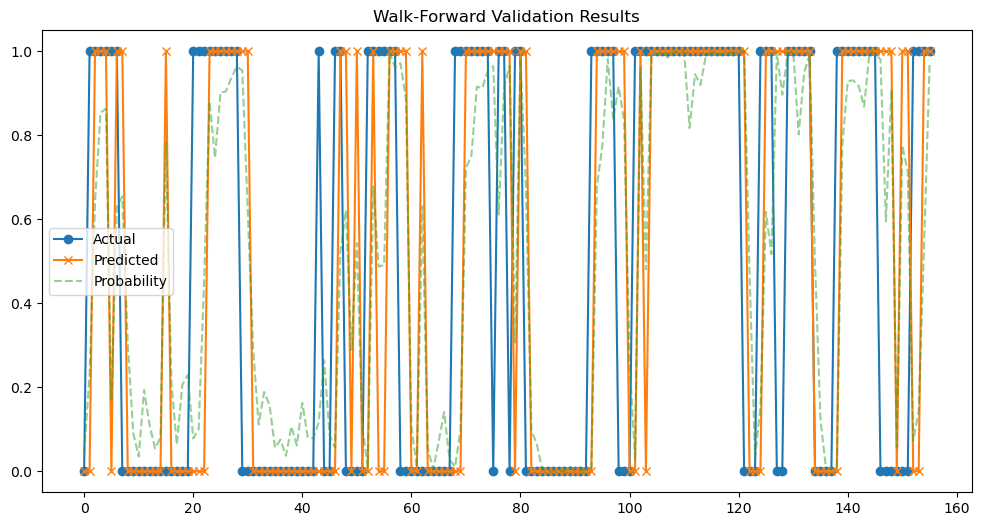

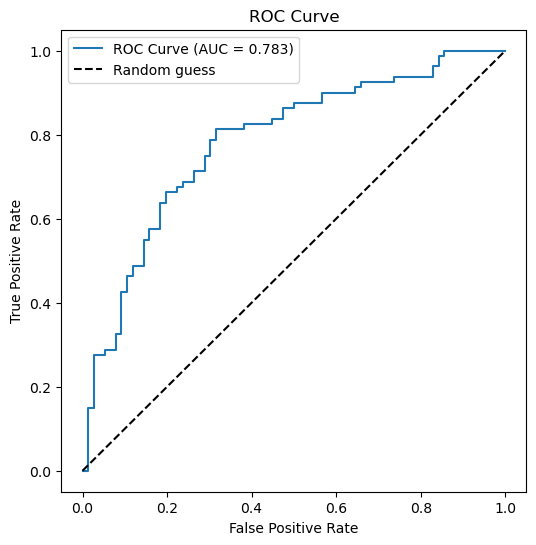

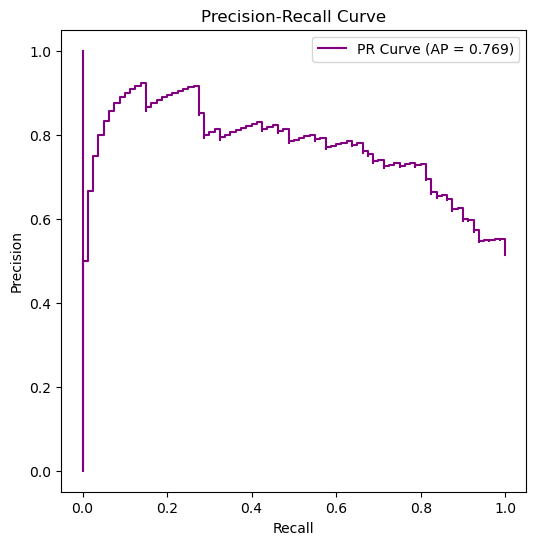

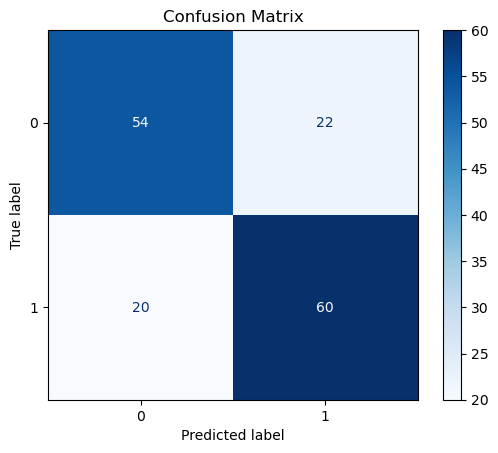

In [40]:
def main():
    # Prepare data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    # Handle inf/NaN (XGBoost handles NaNs natively, but we cap inf)
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

    print("=== PHASE 1: INITIAL HYPERPARAMETER TUNING ===")
    # You may want to tune only on pre-test data:
    X_train_full = X[:-FINAL_TEST_POINTS]
    y_train_full = y[:-FINAL_TEST_POINTS]

    best_params = tune_hyperparameters(X_train_full, y_train_full)

    print("\n=== PHASE 2: ADAPTIVE ROLLING WALK-FORWARD ===")
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X, y,
        n_test=FINAL_TEST_POINTS,
        base_params=best_params,
        retune_every=52,      # yearly retuning
        lookback=360          # 5-year rolling window
    )

    print("\n=== ADAPTIVE PARAMS RESULTS ===")
    plot_wfv_results(actuals_adapt, preds_adapt, probs_adapt)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    }


if __name__ == "__main__":
    results_xgb = main()


In [41]:
#results = main()

actuals_adapt = results_xgb["adaptive"][0]
preds_adapt   = results_xgb["adaptive"][1]
probs_adapt   = results_xgb["adaptive"][2]


df_probs = pd.DataFrame({
    "Date": data.index[-len(probs_adapt):],
    "actual": actuals_adapt,
    "prediction": preds_adapt,
    "probability": probs_adapt
}).set_index("Date")


In [42]:
df_probs.to_csv('momentum_value_probs.csv',index=True)

In [43]:
print(df_probs)

            actual  prediction  probability
Date                                       
2021-01-11       0           0     0.041960
2021-01-18       1           0     0.229599
2021-01-25       1           1     0.641587
2021-02-01       1           1     0.853772
2021-02-08       1           1     0.863178
...            ...         ...          ...
2023-12-04       0           1     0.713293
2023-12-11       1           0     0.072906
2023-12-18       1           0     0.142293
2023-12-25       1           1     0.541526
2024-01-01       1           1     0.968559

[156 rows x 3 columns]


c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:32:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost SHAP Global Importance ===
SA_RB_Curvature                          0.511021
relvol_value_vs_quality_12               0.380955
GlobalPropertyVol12                      0.343464
GLD_RollSkew                             0.338337
relvol_momentum_vs_quality_12            0.308230
corr_momentum_value_12                   0.270104
TOP40.Index.Price.to.Ebitda_Diff         0.147758
GLD_RollSD                               0.144425
TOP40.Index.Price.to.Book.Ratio_Diff     0.113931
GlobalBondVol6                           0.111070
relvol_momentum_vs_value_12              0.109550
USDZAR_EntDyn                            0.106407
GlobalEquityTS                           0.094785
MXWD.Index.PE.Ratio_QS                   0.093669
RandPPP_Factor_Inst_TS_ST                0.087862
VolTermStructPC2                         0.087393
US_RB_Curvature                          0.084617
GLD_RollKurt                             0.077438
GLD_LempZiev                             0.073783
JALSH.Inde

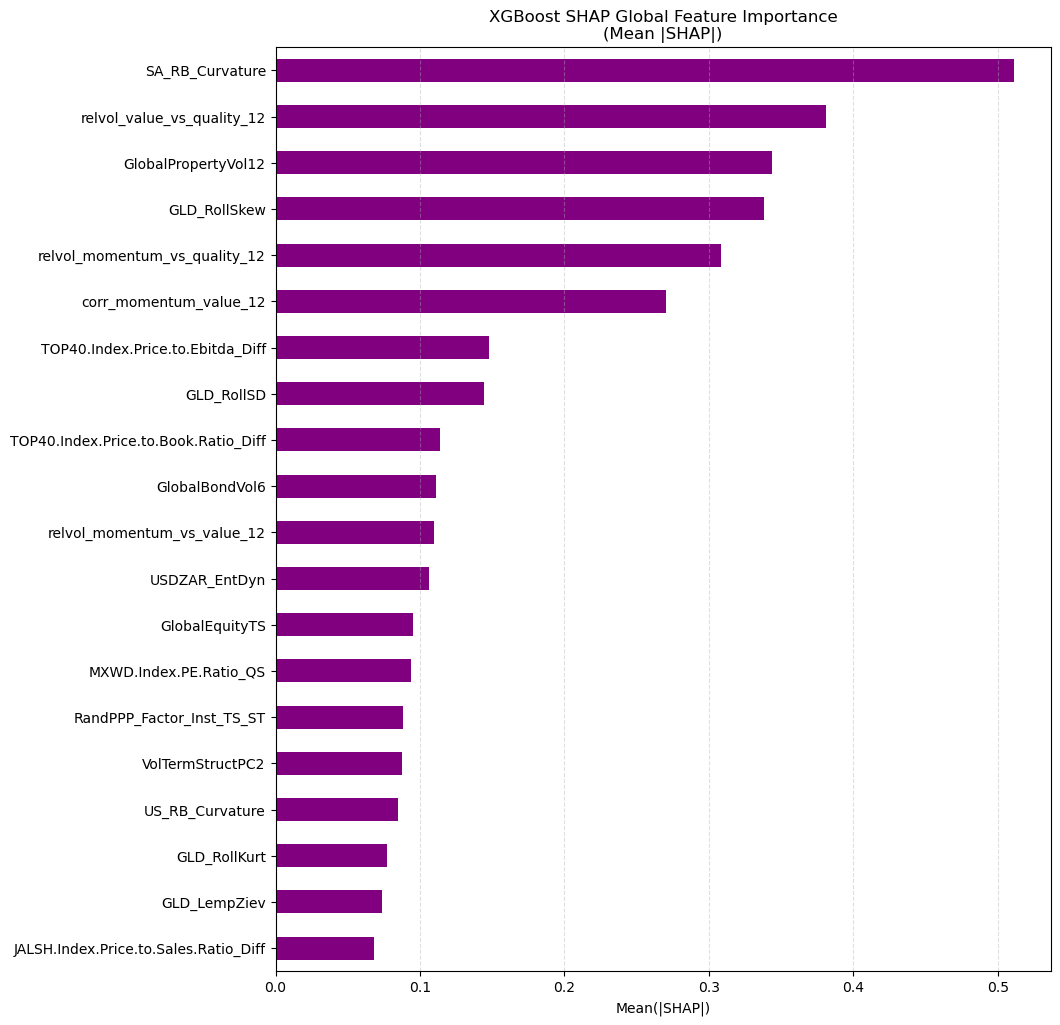

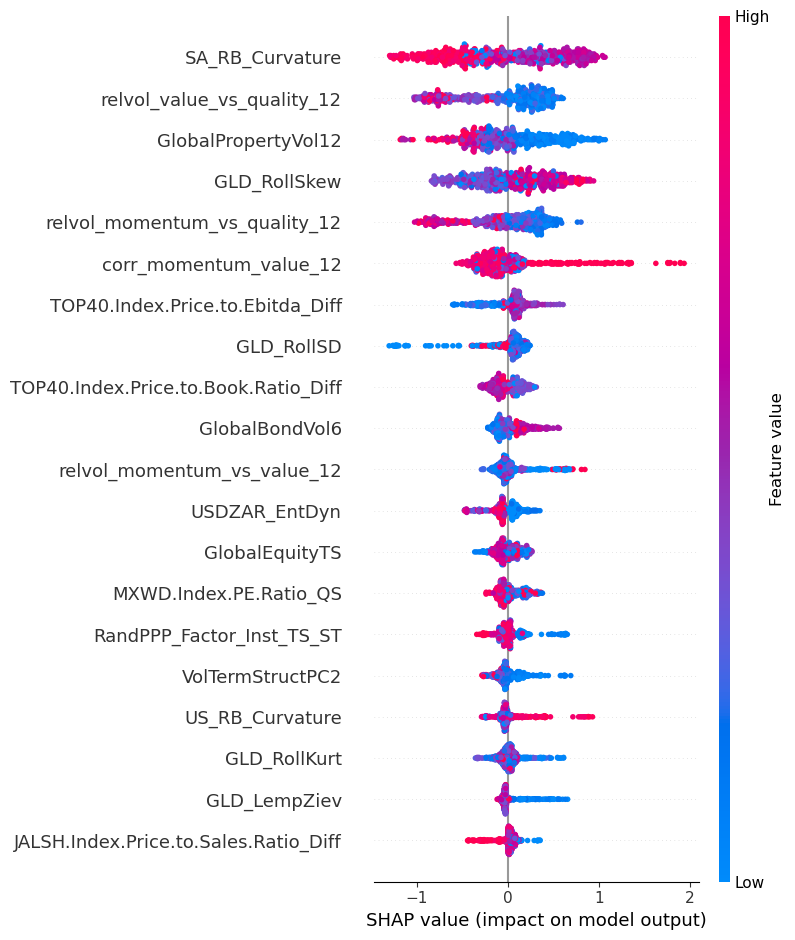

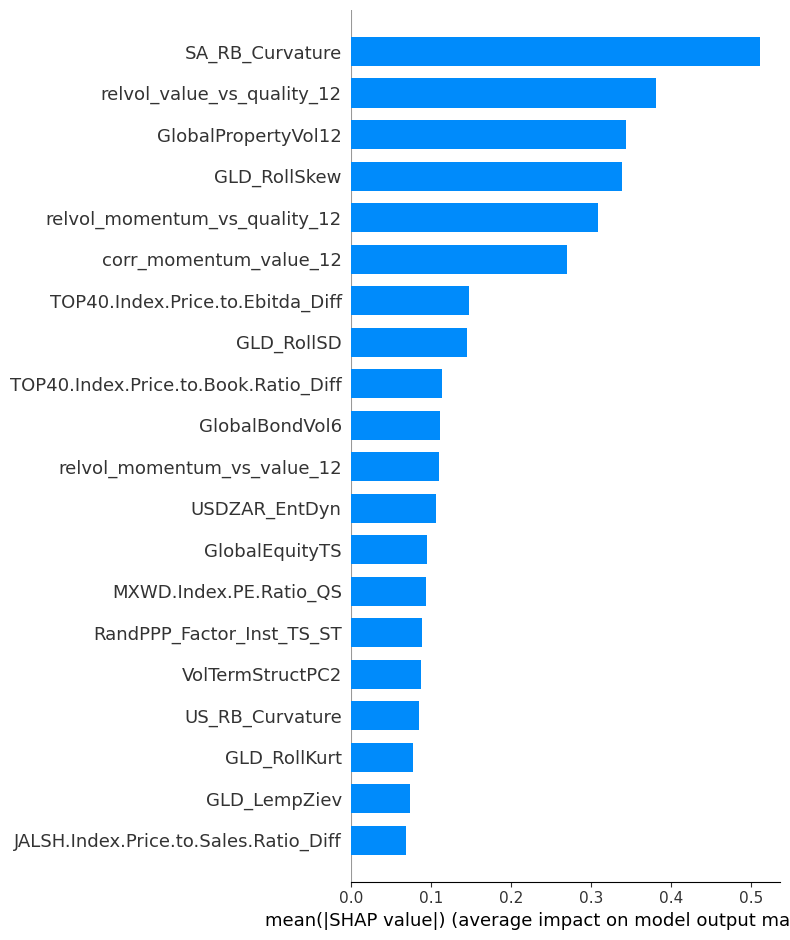

In [ ]:
# ============================================
# XGBoost SHAP FEATURE IMPORTANCE (TREE SHAP)
# ============================================

import shap

# Data prep
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
feature_names = results_xgb["feature_names"]
X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

train_end = len(X) - FINAL_TEST_POINTS
X_train_final = X[:train_end]
y_train_final = y[:train_end]

# Final model
best_params = results_xgb["best_params"]

final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
   # use_label_encoder=False,
    **best_params
)
final_model.fit(X_train_final, y_train_final)

# SHAP Values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_final)

# Global importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print("\n=== XGBoost SHAP Global Importance ===")
print(shap_importance.head(20))

# Plot bar chart
plt.figure(figsize=(10, 12))
shap_importance.head(20).plot(kind='barh', color='purple')
plt.title("XGBoost SHAP Global Feature Importance\n(Mean |SHAP|)")
plt.xlabel("Mean(|SHAP|)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# Summary plots
shap.summary_plot(shap_values, X_train_final, feature_names=feature_names, plot_type="dot")
shap.summary_plot(shap_values, X_train_final, feature_names=feature_names, plot_type="bar")
